### Scaling, PCA & Finding Clusters

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from scipy.cluster.hierarchy import dendrogram, linkage
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer
from kneed import KneeLocator

sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 120

In [3]:
df = pd.read_csv('../data/cleaned_data.csv')

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

print("Scaled shape:", X_scaled.shape)
print("Mean of scaled data :", X_scaled.mean().round(4))
print("Std of scaled data :",  X_scaled.std().round(4))

Scaled shape: (8950, 19)
Mean of scaled data : 0.0
Std of scaled data : 1.0


#### PCA

Components to explain 80% variance: 7
Components to explain 90% variance: 9


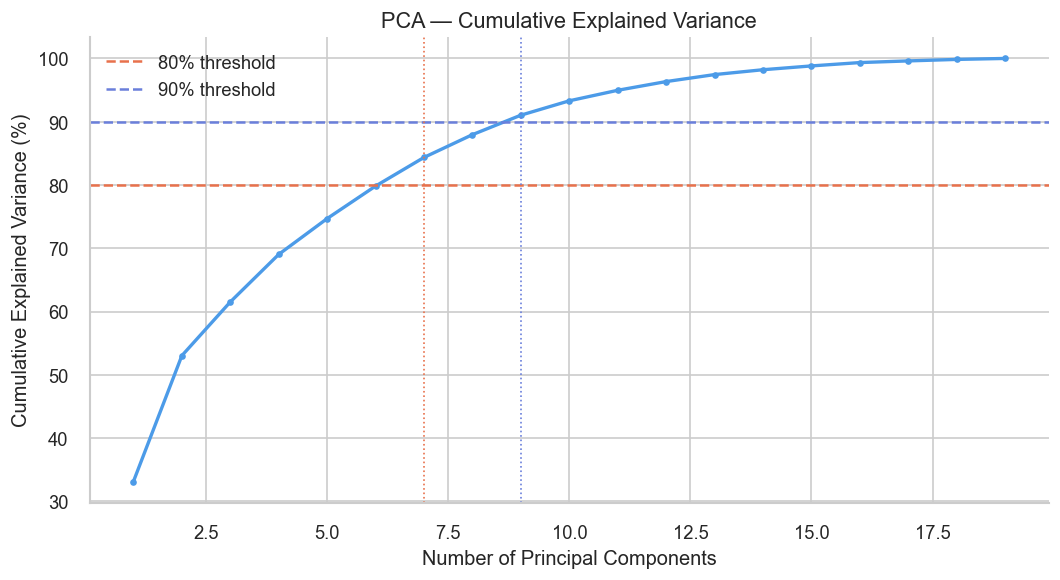

In [4]:
pca = PCA(random_state=0)
pca.fit(X_scaled)

# Cumulative variance
cumvar = np.cumsum(pca.explained_variance_ratio_)

# Number of components explaining 80% and 90% of variance
n_80 = np.argmax(cumvar >= 0.80) + 1
n_90 = np.argmax(cumvar >= 0.90) + 1

print(f"Components to explain 80% variance: {n_80}")
print(f"Components to explain 90% variance: {n_90}")

# Plot
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(range(1, len(cumvar)+1), cumvar * 100,
        marker='o', markersize=4, color='#4C9BE8', lw=2)
ax.axhline(80, color='#E8714C', linestyle='--', lw=1.5, label='80% threshold')
ax.axhline(90, color='#6A7FDB', linestyle='--', lw=1.5, label='90% threshold')
ax.axvline(n_80, color='#E8714C', linestyle=':', lw=1)
ax.axvline(n_90, color='#6A7FDB', linestyle=':', lw=1)
ax.set_xlabel('Number of Principal Components')
ax.set_ylabel('Cumulative Explained Variance (%)')
ax.set_title('PCA — Cumulative Explained Variance', fontsize=13)
ax.legend()
sns.despine()
plt.tight_layout()
plt.savefig('../outputs/03_pca_variance.png')
plt.show()

#### Apply PCA with components explaining 80% variance

In [5]:
pca = PCA(n_components=n_80, random_state=0)
X_pca = pca.fit_transform(X_scaled)

print(f"Reduced from {X_scaled.shape[1]} features to {X_pca.shape[1]} components")
print(f"Total variance explained: {pca.explained_variance_ratio_.sum()*100:.1f}%")

# Show what each component explains individually
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"  PC{i+1}: {var*100:.1f}%")

Reduced from 19 features to 7 components
Total variance explained: 84.4%
  PC1: 33.1%
  PC2: 19.9%
  PC3: 8.5%
  PC4: 7.5%
  PC5: 5.7%
  PC6: 5.1%
  PC7: 4.5%


#### Elbow method to find optimal K

Elbow method suggests: K = 5


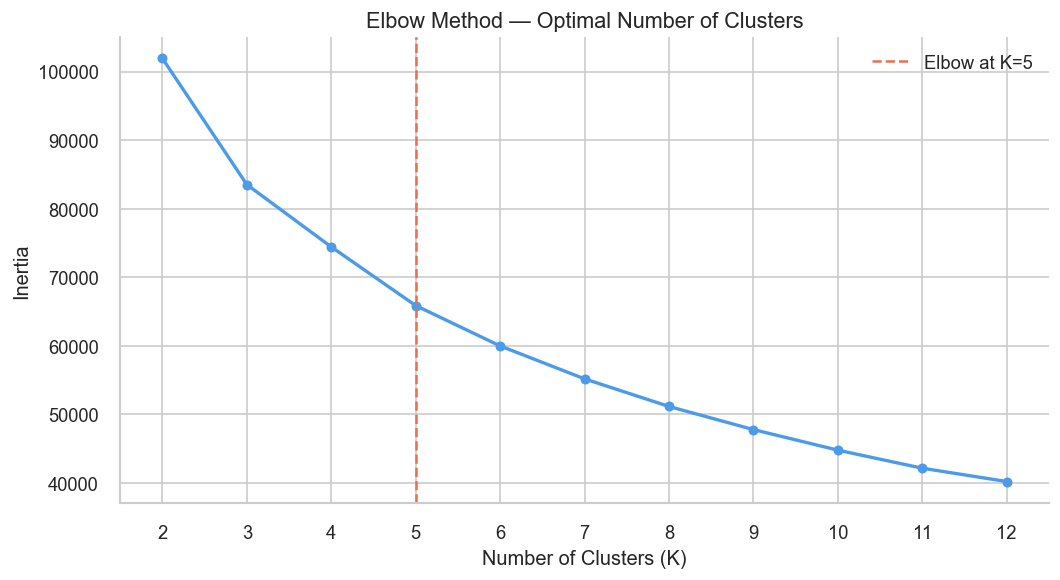

In [6]:
inertias = []
K_range = range(2, 13)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=0, n_init=10)
    km.fit(X_pca)
    inertias.append(km.inertia_)

knee = KneeLocator(list(K_range), inertias,
                   curve='convex', direction='decreasing')
optimal_k_elbow = knee.knee
print(f"Elbow method suggests: K = {optimal_k_elbow}")

# Plot
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(list(K_range), inertias, marker='o', color='#4C9BE8', lw=2, markersize=6)
ax.axvline(optimal_k_elbow, color='#E8714C', linestyle='--',
           lw=1.5, label=f'Elbow at K={optimal_k_elbow}')
ax.set_xlabel('Number of Clusters (K)')
ax.set_ylabel('Inertia')
ax.set_title('Elbow Method — Optimal Number of Clusters', fontsize=13)
ax.set_xticks(list(K_range))
ax.legend()

sns.despine()
plt.tight_layout()
plt.savefig('../outputs/04_elbow_method.png')
plt.show()

#### Silhouette Score for validation

K=2: silhouette score = 0.2954
K=3: silhouette score = 0.2636
K=4: silhouette score = 0.2505
K=5: silhouette score = 0.2598
K=6: silhouette score = 0.2606
K=7: silhouette score = 0.2627
K=8: silhouette score = 0.2402
K=9: silhouette score = 0.2322
K=10: silhouette score = 0.2363
K=11: silhouette score = 0.2368
K=12: silhouette score = 0.2387

Silhouette method suggests: K = 2


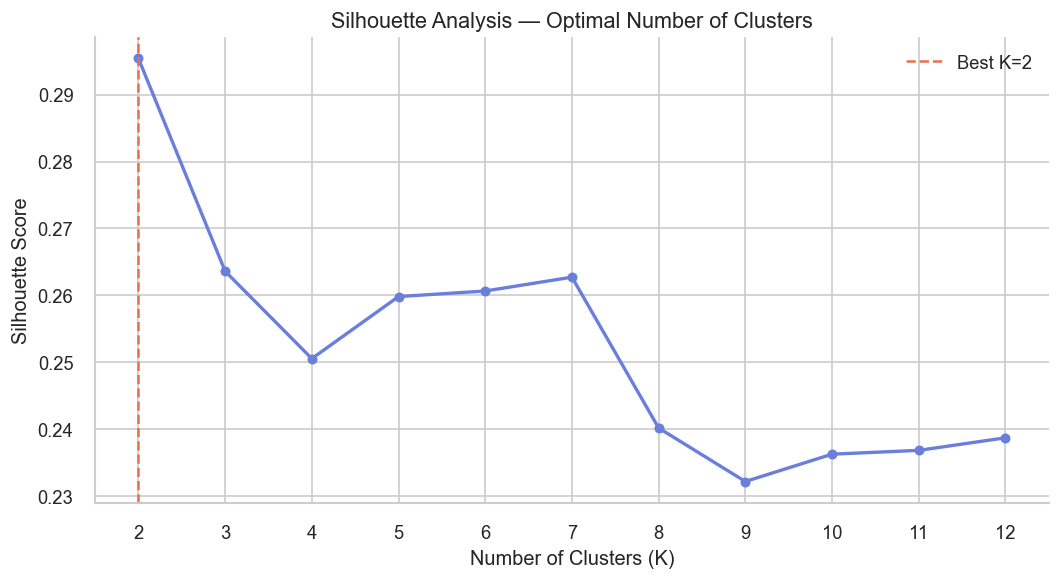

In [7]:
silhouette_scores = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)
    silhouette_scores.append(score)
    print(f"K={k}: silhouette score = {score:.4f}")

optimal_k_sil = list(K_range)[np.argmax(silhouette_scores)]
print(f"\nSilhouette method suggests: K = {optimal_k_sil}")

# Plot
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(list(K_range), silhouette_scores,
        marker='o', color='#6A7FDB', lw=2, markersize=6)
ax.axvline(optimal_k_sil, color='#E8714C', linestyle='--',
           lw=1.5, label=f'Best K={optimal_k_sil}')
ax.set_xlabel('Number of Clusters (K)')
ax.set_ylabel('Silhouette Score')
ax.set_title('Silhouette Analysis — Optimal Number of Clusters', fontsize=13)
ax.set_xticks(list(K_range))
ax.legend()
sns.despine()
plt.tight_layout()
plt.savefig('../outputs/05_silhouette_scores.png')
plt.show()

#### Hierarchical clustering as validation

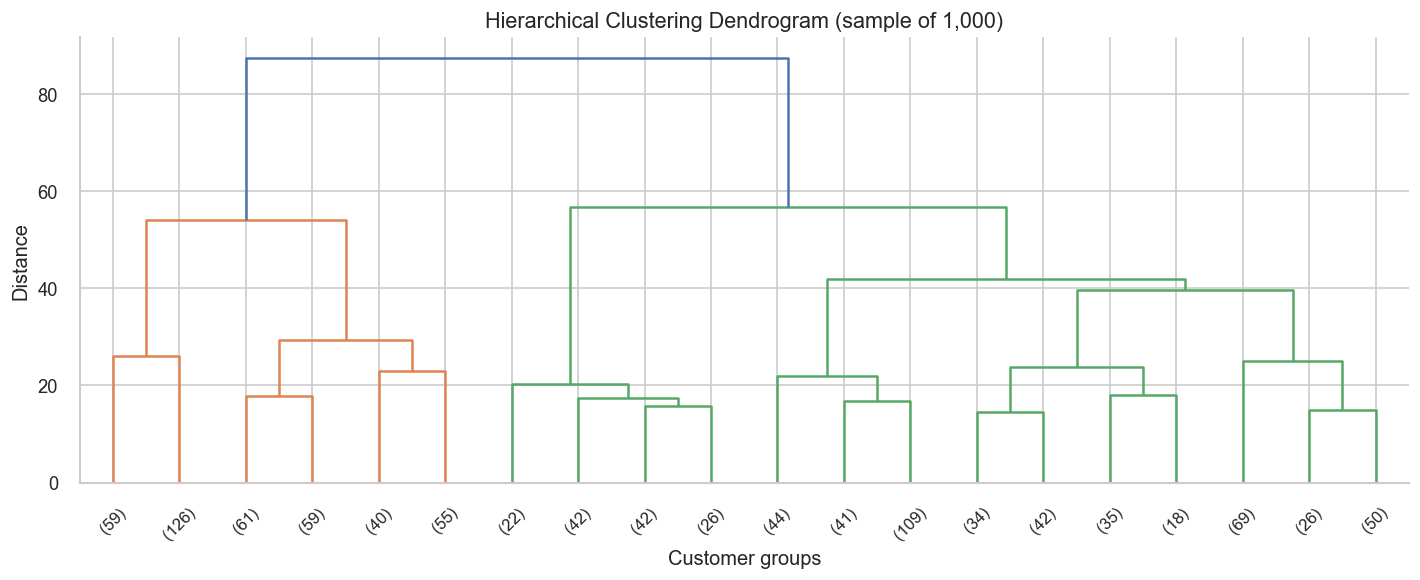

In [8]:
np.random.seed(0)
sample_idx = np.random.choice(len(X_pca), 1000, replace=False)
X_sample = X_pca[sample_idx]

linked = linkage(X_sample, method='ward')

fig, ax = plt.subplots(figsize=(12, 5))
dendrogram(linked, ax=ax, truncate_mode='lastp', p=20,
           leaf_rotation=45, leaf_font_size=10,
           color_threshold=0.7*max(linked[:,2]))

ax.set_title('Hierarchical Clustering Dendrogram (sample of 1,000)', fontsize=13)
ax.set_xlabel('Customer groups')
ax.set_ylabel('Distance')
sns.despine()
plt.tight_layout()
plt.savefig('../outputs/06_dendrogram.png')
plt.show()

### Fit Final Model & Profile the Clusters

#### Fit final K-Means with K=5

In [9]:
K_FINAL = 5

kmeans = KMeans(n_clusters=K_FINAL, random_state=0, n_init=20)
cluster_labels = kmeans.fit_predict(X_pca)

df['Cluster'] = cluster_labels

print("Cluster sizes:")
print(df['Cluster'].value_counts().sort_index())
print(f"\nFinal silhouette score: {silhouette_score(X_pca, cluster_labels):.4f}")

Cluster sizes:
Cluster
0    2195
1    1930
2    1625
3    1784
4    1416
Name: count, dtype: int64

Final silhouette score: 0.2596


#### Visualisation of clusters in 2D (PCA space)

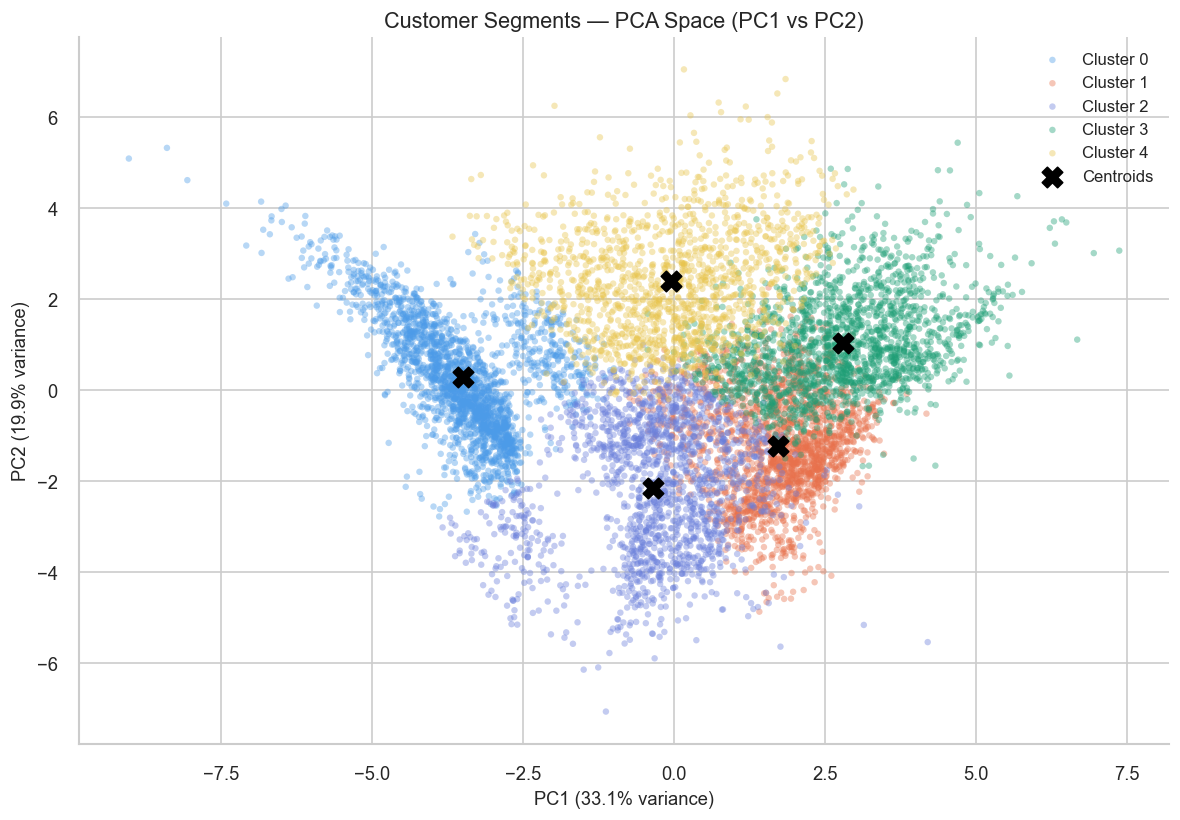

In [10]:
fig, ax = plt.subplots(figsize=(10, 7))

colors = ['#4C9BE8', '#E8714C', '#6A7FDB', '#1D9E75', '#E8C44C', "#E84CE3", "#E6813E"]
cluster_names = ['Cluster 0', 'Cluster 1', 'Cluster 2', 'Cluster 3', 'Cluster 4', 'Cluster 5', 'Cluster 6']

for i in range(K_FINAL):
    mask = cluster_labels == i
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=colors[i], label=cluster_names[i],
               alpha=0.4, s=15, edgecolors='none')

# Plot centroids
centroids_2d = kmeans.cluster_centers_[:, :2]
ax.scatter(centroids_2d[:, 0], centroids_2d[:, 1],
           c='black', marker='X', s=150, zorder=5, label='Centroids')

ax.set_xlabel('PC1 (33.1% variance)', fontsize=11)
ax.set_ylabel('PC2 (19.9% variance)', fontsize=11)
ax.set_title('Customer Segments — PCA Space (PC1 vs PC2)', fontsize=13)
ax.legend(fontsize=10)
sns.despine()
plt.tight_layout()
plt.savefig('../outputs/07_clusters_pca.png')
plt.show()

#### Profile each cluster on original features

In [11]:
# Calculate mean of each original fetaure per cluster
# Original (non-log-transformed) values for interpretability

profile = df.groupby('Cluster').mean().round(2)

# Select the most business-relevant features for the profile
key_features = [
    'BALANCE', 'PURCHASES', 'CASH_ADVANCE',
    'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS',
    'PRC_FULL_PAYMENT', 'PURCHASES_FREQUENCY',
    'CASH_ADVANCE_FREQUENCY', 'ONEOFF_PURCHASES',
    'INSTALLMENTS_PURCHASES', 'PURCHASE_TO_LIMIT_RATIO',
    'CASH_TO_PURCHASE_RATIO', 'PAYMENT_TO_MINIMUM_RATIO'
]

profile_display = profile[key_features].T
print("Cluster profiles (mean values per cluster):")
print(profile_display.to_string())

Cluster profiles (mean values per cluster):
Cluster                         0     1      2     3     4
BALANCE                      7.36  4.77   4.29  6.61  7.78
PURCHASES                    0.63  6.08   4.74  7.62  6.66
CASH_ADVANCE                 6.93  0.40   1.30  0.68  7.34
CREDIT_LIMIT                 8.04  7.76   7.87  8.47  8.42
PAYMENTS                     6.73  6.19   5.40  7.49  7.36
MINIMUM_PAYMENTS             6.38  5.40   5.07  5.94  6.85
PRC_FULL_PAYMENT             0.03  0.31   0.12  0.26  0.03
PURCHASES_FREQUENCY          0.02  0.81   0.21  0.86  0.66
CASH_ADVANCE_FREQUENCY       0.29  0.01   0.03  0.01  0.35
ONEOFF_PURCHASES             0.54  0.96   3.66  7.08  4.98
INSTALLMENTS_PURCHASES       0.09  6.01   1.54  5.22  4.51
PURCHASE_TO_LIMIT_RATIO      0.01  0.28   0.13  0.65  0.29
CASH_TO_PURCHASE_RATIO    1821.29  0.11  59.40  0.03  5.85
PAYMENT_TO_MINIMUM_RATIO     4.12  4.67  11.07  9.14  3.42


#### Radar chart for each cluster

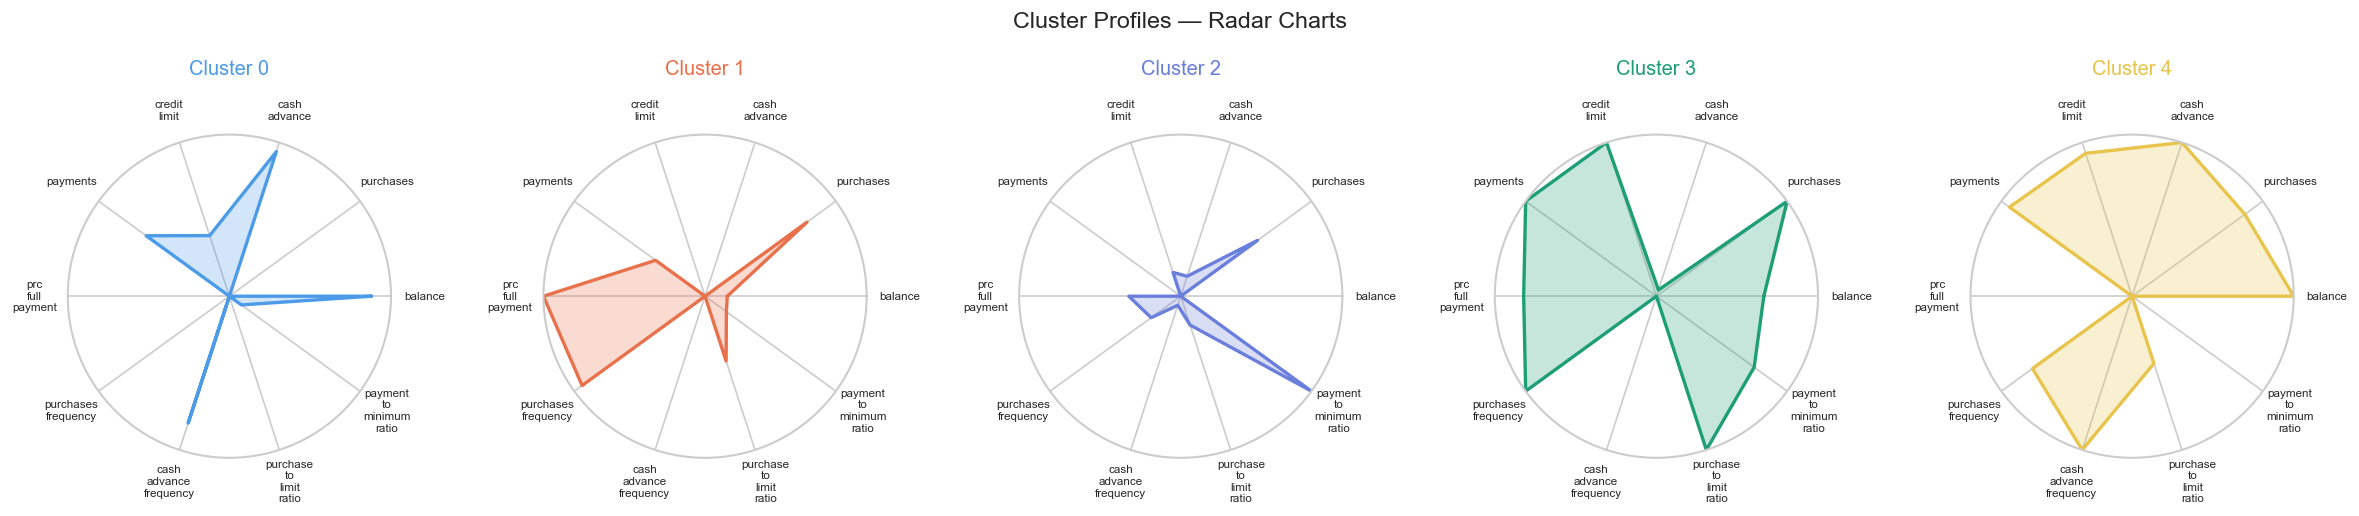

In [12]:
from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as mpatches

# Normalise profile to 0-1 for radar chart
profile_norm = (profile[key_features] - profile[key_features].min()) / \
               (profile[key_features].max() - profile[key_features].min())

features_radar = [
    'BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT',
    'PAYMENTS', 'PRC_FULL_PAYMENT', 'PURCHASES_FREQUENCY',
    'CASH_ADVANCE_FREQUENCY', 'PURCHASE_TO_LIMIT_RATIO',
    'PAYMENT_TO_MINIMUM_RATIO'
]

profile_norm = profile_norm[features_radar]
N = len(features_radar)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, axes = plt.subplots(1, 5, figsize=(20, 4),
                          subplot_kw=dict(polar=True))

colors = ['#4C9BE8', '#E8714C', '#6A7FDB', '#1D9E75', '#E8C44C']

for i, ax in enumerate(axes):
    values = profile_norm.iloc[i].tolist()
    values += values[:1]

    ax.plot(angles, values, color=colors[i], linewidth=2)
    ax.fill(angles, values, color=colors[i], alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels([f.replace('_', '\n').lower()
                        for f in features_radar], size=7)
    ax.set_ylim(0, 1)
    ax.set_title(f'Cluster {i}', size=12, pad=15, color=colors[i])
    ax.set_yticks([])

plt.suptitle('Cluster Profiles — Radar Charts', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../outputs/08_radar_charts.png', bbox_inches='tight')
plt.show()

#### Cluster size bar chart

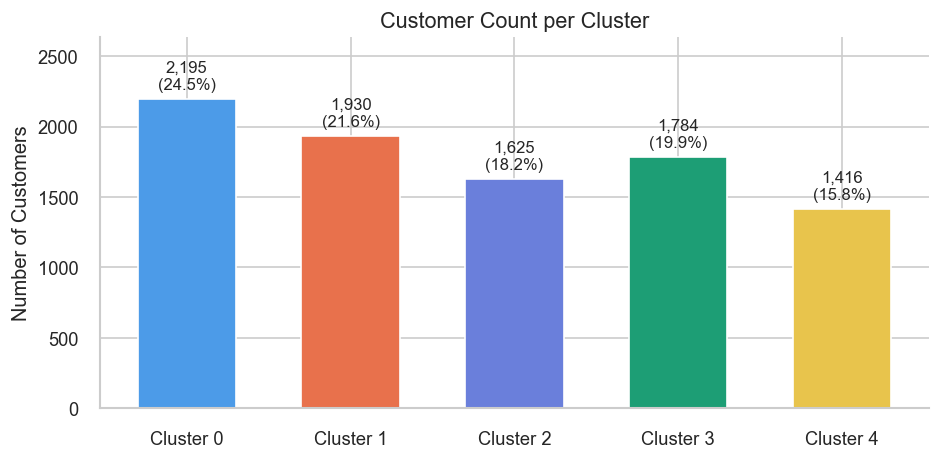

In [13]:
sizes = df['Cluster'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar([f'Cluster {i}' for i in sizes.index],
              sizes.values,
              color=colors, edgecolor='white', width=0.6)

for bar, count in zip(bars, sizes.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 50,
            f'{count:,}\n({count/len(df)*100:.1f}%)',
            ha='center', va='bottom', fontsize=10)

ax.set_title('Customer Count per Cluster', fontsize=13)
ax.set_ylabel('Number of Customers')
ax.set_ylim(0, sizes.max() * 1.2)
sns.despine()
plt.tight_layout()
plt.savefig('../outputs/09_cluster_sizes.png')
plt.show()

#### Save clustered data

In [14]:
df.to_csv('../data/clustered_data.csv', index=False)
print("Saved.")

Saved.


#### Named segment summary chart

In [15]:
segment_names = {
    0: 'Cash Borrowers',
    1: 'Installment Shoppers',
    2: 'Infrequent Big Spenders',
    3: 'High Value Users',
    4: 'Revolvers'
}

segment_colors = {
    0: '#4C9BE8',
    1: '#E8714C',
    2: '#6A7FDB',
    3: '#1D9E75',
    4: '#E8C44C'
}

df['Segment'] = df['Cluster'].map(segment_names)

# Key metrics to compare across segments using original scale
# Original cleaned data used for interpretable values
df_orig = pd.read_csv('../data/cleaned_data.csv')
df_orig['Cluster'] = cluster_labels
df_orig['Segment'] = df_orig['Cluster'].map(segment_names)

metrics = {
    'Avg Balance ($)':            'BALANCE',
    'Avg Monthly Purchases ($)':  'PURCHASES',
    'Avg Cash Advance ($)':       'CASH_ADVANCE',
    'Avg Credit Limit ($)':       'CREDIT_LIMIT',
    'Full Payment Rate':          'PRC_FULL_PAYMENT',
    'Purchase Frequency':         'PURCHASES_FREQUENCY',
}

summary = df_orig.groupby('Segment')[list(metrics.values())].mean()
summary.columns = list(metrics.keys())
summary = summary.loc[[segment_names[i] for i in range(5)]]

print("=== FINAL SEGMENT PROFILES (original scale) ===\n")
print(summary.round(2).to_string())

=== FINAL SEGMENT PROFILES (original scale) ===

                         Avg Balance ($)  Avg Monthly Purchases ($)  Avg Cash Advance ($)  Avg Credit Limit ($)  Full Payment Rate  Purchase Frequency
Segment                                                                                                                                               
Cash Borrowers                      7.36                       0.63                  6.93                  8.04               0.03                0.02
Installment Shoppers                4.77                       6.08                  0.40                  7.76               0.31                0.81
Infrequent Big Spenders             4.29                       4.74                  1.30                  7.87               0.12                0.21
High Value Users                    6.61                       7.62                  0.68                  8.47               0.26                0.86
Revolvers                           7.78     

In [16]:
# The cleaned_data.csv has log-transformed values
# We need to reverse the log transform with np.expm1 (inverse of log1p)

log_cols = ['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT',
            'PAYMENTS', 'MINIMUM_PAYMENTS', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX',
            'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES']

df_real = df_orig.copy()
for col in log_cols:
    df_real[col] = np.expm1(df_orig[col])

summary_real = df_real.groupby('Segment')[list(metrics.values())].mean()
summary_real.columns = list(metrics.keys())
summary_real = summary_real.loc[[segment_names[i] for i in range(5)]]

print("=== FINAL SEGMENT PROFILES (real dollar values) ===\n")
print(summary_real.round(2).to_string())

=== FINAL SEGMENT PROFILES (real dollar values) ===

                         Avg Balance ($)  Avg Monthly Purchases ($)  Avg Cash Advance ($)  Avg Credit Limit ($)  Full Payment Rate  Purchase Frequency
Segment                                                                                                                                               
Cash Borrowers                   2327.02                      17.00               2087.44               4164.02               0.03                0.02
Installment Shoppers              436.01                     612.26                 32.99               3104.41               0.31                0.81
Infrequent Big Spenders           392.25                     328.20                138.95               3580.46               0.12                0.21
High Value Users                 1527.71                    3037.71                 67.16               6175.13               0.26                0.86
Revolvers                        3312.09 

#### Heatmap of segment profiles

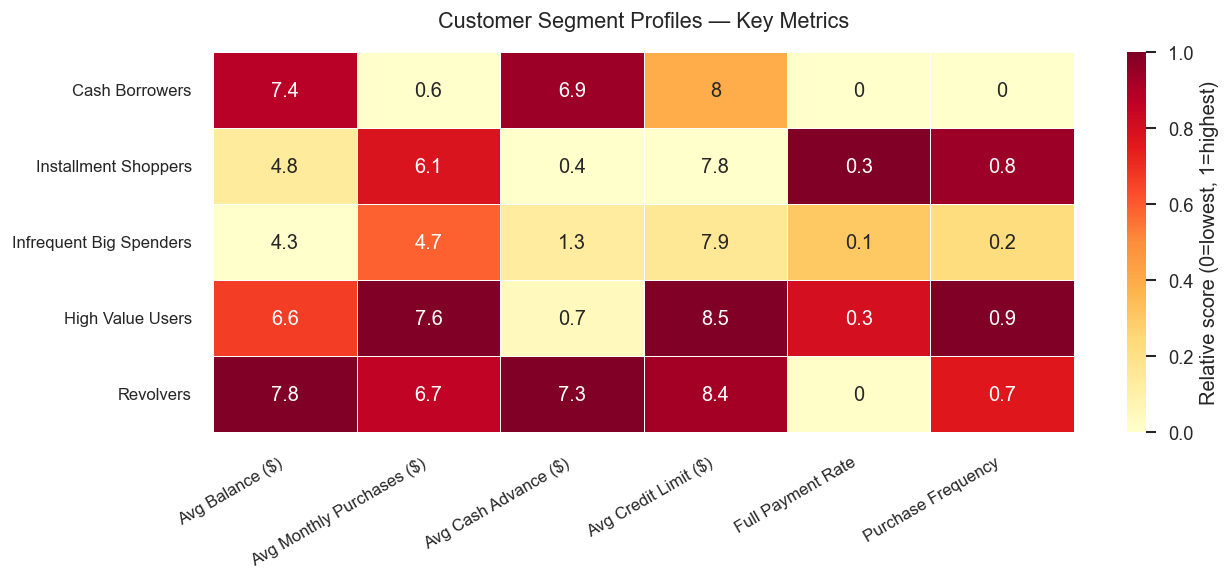

In [17]:
from sklearn.preprocessing import MinMaxScaler

# Normalise for heatmap display
scaler_mm = MinMaxScaler()
summary_norm = pd.DataFrame(
    scaler_mm.fit_transform(summary),
    index=summary.index,
    columns=summary.columns
)

fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(summary_norm, annot=summary.round(1), fmt='g',
            cmap='YlOrRd', linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Relative score (0=lowest, 1=highest)'})

ax.set_title('Customer Segment Profiles — Key Metrics', fontsize=13, pad=15)
ax.set_xlabel('')
ax.set_ylabel('')
plt.xticks(rotation=30, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.savefig('../outputs/10_segment_heatmap.png', bbox_inches='tight')
plt.show()

#### Business recommendations summary

In [ ]:
recommendations = {
    'Cash Borrowers': (
        'High risk. Monitor for default. Offer debt consolidation '
        'products and financial wellness tools. Limit cash advance limits.'
    ),
    'Installment Shoppers': (
        'Loyal, low-risk. Promote installment offers and partnerships '
        'with retail merchants. Good candidates for credit limit increases.'
    ),
    'Infrequent Big Spenders': (
        'High potential. Re-engage with targeted campaigns around '
        'travel, electronics, and premium categories. Offer rewards.'
    ),
    'High Value Users': (
        'Best customers. Retain with premium loyalty rewards, '
        'concierge services, and exclusive offers. Protect from churn.'
    ),
    'Revolvers': (
        'Revenue-generating but at-risk. Offer balance transfer deals '
        'and structured repayment plans to reduce default risk.'
    ),
}

print("=" * 62)
print("BUSINESS RECOMMENDATIONS BY CUSTOMER SEGMENT")
print("=" * 62)
for segment, rec in recommendations.items():
    count = (df_orig['Segment'] == segment).sum()
    pct = count / len(df_orig) * 100
    print(f"\n{segment} ({count:,} customers, {pct:.1f}%)")
    print(f"  {rec}")
print("\n" + "=" * 62)

BUSINESS RECOMMENDATIONS BY CUSTOMER SEGMENT

Cash Borrowers (2,195 customers, 24.5%)
  ⚠ High risk. Monitor for default. Offer debt consolidation products and financial wellness tools. Limit cash advance limits.

Installment Shoppers (1,930 customers, 21.6%)
  ✓ Loyal, low-risk. Promote installment offers and partnerships with retail merchants. Good candidates for credit limit increases.

Infrequent Big Spenders (1,625 customers, 18.2%)
  ◆ High potential. Re-engage with targeted campaigns around travel, electronics, and premium categories. Offer rewards.

High Value Users (1,784 customers, 19.9%)
  ★ Best customers. Retain with premium loyalty rewards, concierge services, and exclusive offers. Protect from churn.

Revolvers (1,416 customers, 15.8%)
  $ Revenue-generating but at-risk. Offer balance transfer deals and structured repayment plans to reduce default risk.



#### Guassian Mixture Models vs K-Means

In [19]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

gmm = GaussianMixture(n_components=5, random_state=42, n_init=10)
gmm_labels = gmm.fit_predict(X_pca)

# Silhouette scores
kmeans_sil = silhouette_score(X_pca, cluster_labels)
gmm_sil    = silhouette_score(X_pca, gmm_labels)

# Structural agreement — label-order invariant
ari = adjusted_rand_score(cluster_labels, gmm_labels)
nmi = normalized_mutual_info_score(cluster_labels, gmm_labels)

print("=== METHOD COMPARISON: K-Means vs GMM ===\n")
print(f"Silhouette score — K-Means : {kmeans_sil:.4f}")
print(f"Silhouette score — GMM     : {gmm_sil:.4f}")
print(f"\nAdjusted Rand Index (ARI)  : {ari:.4f}")
print(f"  → 1.0 = perfect agreement, 0.0 = random")
print(f"\nNormalized Mutual Info (NMI): {nmi:.4f}")
print(f"  → 1.0 = perfect agreement, 0.0 = no shared structure")

# Cluster sizes for both
print("\nK-Means cluster sizes:")
print(pd.Series(cluster_labels).value_counts().sort_index().to_dict())
print("\nGMM cluster sizes:")
print(pd.Series(gmm_labels).value_counts().sort_index().to_dict())

# Probabilistic assignments — a unique GMM feature
proba = gmm.predict_proba(X_pca)
avg_max_proba = proba.max(axis=1).mean()
uncertain = (proba.max(axis=1) < 0.60).sum()

print(f"\nGMM average assignment confidence: {avg_max_proba*100:.1f}%")
print(f"Customers with <60% confidence in any segment: {uncertain:,} ({uncertain/len(proba)*100:.1f}%)")
print("  → These are borderline customers K-Means forces into one box")

=== METHOD COMPARISON: K-Means vs GMM ===

Silhouette score — K-Means : 0.2596
Silhouette score — GMM     : 0.1690

Adjusted Rand Index (ARI)  : 0.4217
  → 1.0 = perfect agreement, 0.0 = random

Normalized Mutual Info (NMI): 0.4758
  → 1.0 = perfect agreement, 0.0 = no shared structure

K-Means cluster sizes:
{0: 2195, 1: 1930, 2: 1625, 3: 1784, 4: 1416}

GMM cluster sizes:
{0: 1452, 1: 2513, 2: 2390, 3: 1730, 4: 865}

GMM average assignment confidence: 95.6%
Customers with <60% confidence in any segment: 234 (2.6%)
  → These are borderline customers K-Means forces into one box


In [20]:
comparison_results = {
    'kmeans_silhouette': round(kmeans_sil, 4),
    'gmm_silhouette':    round(gmm_sil, 4),
    'ari':               round(ari, 4),
    'nmi':               round(nmi, 4),
    'gmm_confidence':    round(avg_max_proba, 4),
    'uncertain_customers': int(uncertain)
}

import json
with open('../outputs/method_comparison.json', 'w') as f:
    json.dump(comparison_results, f, indent=2)

print("Comparison results saved.")


Comparison results saved.


#### Export for Power BI dashboard

In [21]:
dashboard_df = df_real.copy()
dashboard_df['Cluster'] = cluster_labels
dashboard_df['Segment'] = dashboard_df['Cluster'].map(segment_names)

# Round monetary columns to 2 decimal places for clean display
money_cols = ['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT',
              'PAYMENTS', 'MINIMUM_PAYMENTS', 'ONEOFF_PURCHASES',
              'INSTALLMENTS_PURCHASES']
dashboard_df[money_cols] = dashboard_df[money_cols].round(2)

dashboard_df.to_csv('../outputs/dashboard_data.csv', index=False)
print("Exported. Shape:", dashboard_df.shape)
print("Columns:", dashboard_df.columns.tolist())

Exported. Shape: (8950, 21)
Columns: ['BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'PURCHASE_TO_LIMIT_RATIO', 'CASH_TO_PURCHASE_RATIO', 'PAYMENT_TO_MINIMUM_RATIO', 'Cluster', 'Segment']
